Training on device: cuda
Training REINFORCE Agent...


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [05:46<00:00,  2.88it/s]


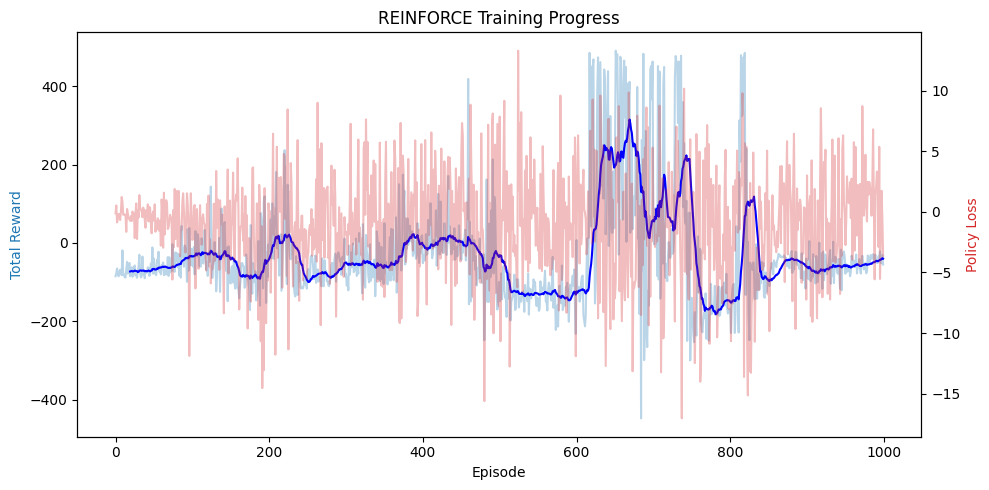

Training complete! Best 20-episode average: 314.93
Weights loaded from best_reinforce_cartpole.pth
Recording to reinforce_vs_drift.mp4...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Episode 1 Score: 176.46841430664062
Episode 2 Score: 262.450439453125
Episode 3 Score: 115.74502563476562
Episode 4 Score: 301.6160888671875
Episode 5 Score: 327.0630187988281
Episode 6 Score: 161.98056030273438
Episode 7 Score: 103.72264099121094
Episode 8 Score: 307.26751708984375
Episode 9 Score: 196.12969970703125
Episode 10 Score: 242.89544677734375


In [4]:
import numpy as np
import gymnasium as gym
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# 1. The Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(PolicyNetwork, self).__init__()
        # Similar MLP, but the output represents action preferences
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        # Softmax converts raw preferences into a probability distribution (summing to 1)
        return torch.softmax(self.fc3(x), dim=-1)

# 2. The REINFORCE Agent
class ReinforceCartPole:
    def __init__(self, lr=1e-3, gamma=0.99):
        self.env = gym.make('CartPole-v1')
        self.state_size = self.env.observation_space.shape[0]
        self.action_size = self.env.action_space.n
        
        # Hyperparameters (Notice: No epsilon, no buffer size!)
        self.gamma = gamma
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Training on device: {self.device}")

        self.policy_network = PolicyNetwork(self.state_size, self.action_size).to(self.device)
        self.optimizer = optim.Adam(self.policy_network.parameters(), lr=lr)
        
        # History tracking
        self.reward_history = []
        self.loss_history = []

    def get_action(self, state):
        """Samples an action from the probability distribution."""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        
        # Get action probabilities from the network
        probs = self.policy_network(state_tensor)
        
        # Create a Categorical distribution to sample from
        m = Categorical(probs)
        action = m.sample()
        
        # Return the chosen action and the log probability of that action (needed for math)
        return action.item(), m.log_prob(action)

    def train_episode(self):
        """Plays a full episode, then calculates gradients and updates weights."""
        obs, _ = self.env.reset()
        done = False
        
        # Temporary storage for a single trajectory (episode)
        saved_log_probs = []
        rewards = []
        
        # --- 1. Play out the entire episode ---
        while not done:
            action, log_prob = self.get_action(obs)
            next_obs, reward, term, trunc, _ = self.env.step(action)
            done = term or trunc
            
            # Custom Reward (keeping your logic)
            if term:
                r = -100.0
            else:
                r = 1.0 - (next_obs[0]**2) - (next_obs[2]**2)
            
            saved_log_probs.append(log_prob)
            rewards.append(r)
            obs = next_obs
            
        ep_reward = sum(rewards)
        self.reward_history.append(ep_reward)

        # --- 2. Calculate Discounted Returns (Gt) backward ---
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
            
        returns = torch.tensor(returns).to(self.device)
        
        # Normalize returns to reduce variance in gradients (Standard trick)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # --- 3. Compute Policy Gradient Loss ---
        policy_loss = []
        for log_prob, Gt in zip(saved_log_probs, returns):
            # We use negative log prob because PyTorch optimizers minimize loss, 
            # but we want to MAXIMIZE the objective function J(theta).
            policy_loss.append(-log_prob * Gt)
            
        # Sum the loss for the whole trajectory
        loss = torch.cat(policy_loss).sum()
        
        # --- 4. Backpropagate ---
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.loss_history.append(loss.item())
        return ep_reward

    def train(self, num_episodes):
        print("Training REINFORCE Agent...")
        best_avg_reward = -float('inf') 
        window_size = 20
        
        for ep in tqdm(range(1, num_episodes + 1)):
            self.train_episode()
            
            # Checkpoint the best weights
            if len(self.reward_history) >= window_size:
                current_avg = np.mean(self.reward_history[-window_size:])
                if current_avg > best_avg_reward:
                    best_avg_reward = current_avg
                    self.save_weights("best_reinforce_cartpole.pth")
                    
        self.plot_learning_curve(self.reward_history, self.loss_history)
        print(f"Training complete! Best {window_size}-episode average: {best_avg_reward:.2f}")

    def plot_learning_curve(self, rewards, losses):
        fig, ax1 = plt.subplots(figsize=(10, 5))

        ax1.set_xlabel('Episode')
        ax1.set_ylabel('Total Reward', color='tab:blue')
        ax1.plot(rewards, color='tab:blue', alpha=0.3, label="Raw Reward")
        
        window = 20
        if len(rewards) > window:
            avg_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
            ax1.plot(range(window-1, len(rewards)), avg_rewards, color='blue', label="Moving Avg")
        
        ax2 = ax1.twinx()
        ax2.set_ylabel('Policy Loss', color='tab:red')
        ax2.plot(losses, color='tab:red', alpha=0.3)
        
        plt.title("REINFORCE Training Progress")
        fig.tight_layout()
        plt.show()

    def save_weights(self, filename="reinforce_weights.pth"):
        torch.save(self.policy_network.state_dict(), filename)

    def load_weights(self, filename="reinforce_weights.pth"):
        if os.path.exists(filename):
            self.policy_network.load_state_dict(torch.load(filename, map_location=self.device))
            print(f"Weights loaded from {filename}")

    def create_concatenated_video(self, output_name="reinforce_performance.mp4", num_episodes=10):
        env = gym.make('CartPole-v1', render_mode="rgb_array")
        obs, _ = env.reset()
        frame = env.render()
        height, width, _ = frame.shape
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        video = cv2.VideoWriter(output_name, fourcc, 24, (width, height))

        print(f"Recording to {output_name}...")

        for ep in range(1, num_episodes + 1):
            obs, _ = env.reset()
            done = False
            score = 0
            step = 0
            
            while not done:
                # For testing, we just pick the action with the highest probability
                state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    probs = self.policy_network(state_tensor)
                action = torch.argmax(probs).item()

                obs, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                score += (1.0 - obs[0]**2 - obs[2]**2) if not done else -100
                step += 1

                frame_bgr = cv2.cvtColor(env.render(), cv2.COLOR_RGB2BGR)
                cv2.rectangle(frame_bgr, (5, 5), (150, 75), (255, 255, 255), -1)
                
                lines = [(f"Episode: {ep}", 25), (f"Score: {int(score)}", 45), (f"Step: {step}", 65)]
                for text, y_pos in lines:
                    cv2.putText(frame_bgr, text, (15, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

                video.write(frame_bgr)
            print(f"Episode {ep} Score: {score}")

        video.release()
        env.close()

# Initialize and Train
agent = ReinforceCartPole(lr=1e-3, gamma=0.99)
agent.train(num_episodes=1000)

# Load best and Record
agent.load_weights("best_reinforce_cartpole.pth")
agent.create_concatenated_video("reinforce_vs_drift.mp4", num_episodes=10)